**FNN using DeepXDE module**

In [1]:
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Data loading

In [2]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5", 'r')
data_I = np.array(np.array(datastore["I"]))

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))
t = np.linspace(0, 1, 601).reshape(601, 1)

Train-test split

In [3]:
train_label, test_label = train_test_split(range(len(data_I)), test_size=0.25, random_state=42)

data_i_train = data_I[train_label,:]
data_i_test = data_I[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [4]:
# from sklearn.metrics import mean_squared_error

# Train PCA model
pca_i = PCA(n_components=0.999, svd_solver='full')
pca_i.fit(data_i_train)

# Number of principal components
n_components = pca_i.n_components_
print(f"Number of principal components: {n_components}")

# Transform and inverse transform data_i_train
data_i_train_pca = pca_i.transform(data_i_train)
data_i_train_reconstructed = pca_i.inverse_transform(data_i_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_i_train - data_i_train_reconstructed)**2)
print(f"Mean Squared Error for data_i_train: {mse_train}")

# Transform and inverse transform data_i_test
data_i_test_pca = pca_i.transform(data_i_test)
data_i_test_reconstructed = pca_i.inverse_transform(data_i_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_i_test - data_i_test_reconstructed)**2)
print(f"Mean Squared Error for data_i_test: {mse_test}")

Number of principal components: 10
Mean Squared Error for data_i_train: 1.1258045873319134e-07
Mean Squared Error for data_i_test: 1.1333015237369182e-07


In [5]:
# from sklearn.metrics import mean_squared_error

# Train PCA model
pca_c = PCA(n_components=0.99999, svd_solver='full')
pca_c.fit(data_c_train)

# Number of principal components
n_components = pca_c.n_components_
print(f"Number of principal components: {n_components}")

# Transform and inverse transform data_i_train
data_c_train_pca = pca_c.transform(data_c_train)
data_c_train_reconstructed = pca_c.inverse_transform(data_c_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_c_train - data_c_train_reconstructed)**2)
print(f"Mean Squared Error for data_c_train: {mse_train}")

# Transform and inverse transform data_i_test
data_c_test_pca = pca_c.transform(data_c_test)
data_c_test_reconstructed = pca_c.inverse_transform(data_c_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_c_test - data_c_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")

Number of principal components: 26
Mean Squared Error for data_c_train: 6.611593562411144e-05
Mean Squared Error for data_c_test: 6.939424929441884e-05


In [6]:
# from sklearn.metrics import mean_squared_error

# Train PCA model
pca_h = PCA(n_components=0.9999, svd_solver='full')
pca_h.fit(data_h_train)

# Number of principal components
n_components = pca_h.n_components_
print(f"Number of principal components: {n_components}")

# Transform and inverse transform data_i_train
data_h_train_pca = pca_h.transform(data_h_train)
data_h_train_reconstructed = pca_h.inverse_transform(data_h_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_h_train - data_h_train_reconstructed)**2)
print(f"Mean Squared Error for data_h_train: {mse_train}")

# Transform and inverse transform data_i_test
data_h_test_pca = pca_h.transform(data_h_test)
data_h_test_reconstructed = pca_h.inverse_transform(data_h_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_h_test - data_h_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")

Number of principal components: 10
Mean Squared Error for data_h_train: 2.8779925287381047e-06
Mean Squared Error for data_c_test: 2.9592906685138587e-06


In [7]:
X_train = data_i_train_pca.astype(np.float32)
y_train_c = data_c_train_pca.astype(np.float32)

In [8]:
X_test = data_i_test_pca.astype(np.float32)
y_test_c = data_c_test_pca.astype(np.float32)

In [9]:
data_c = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)

In [10]:
m = 601
dim_x = 1
net_c = dde.nn.fnn.FNN(
    [10, 400, 300, 200, 26],
    "relu",
    "Glorot normal",
)

In [11]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [10, 400, 300, 200, 26]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 190126


In [12]:
model_c = dde.Model(data_c, net_c)
model_c.compile("adam", lr=0.001, metrics=["l2 relative error"])
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_fnn_pca-1800.pt"
model_c.restore(path)
# losshistory_c, train_state_c = model_c.train(iterations=1800, display_every=100)

Compiling model...
'compile' took 2.041625 s



c:\Users\arnab\anaconda3\envs\deepxde\Lib\site-packages\deepxde\model.py:1096: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path)


In [13]:
y_train_h = data_h_train_pca.astype(np.float32)
y_test_h = data_h_test_pca.astype(np.float32)

In [14]:
data_h = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

In [15]:
m = 601
dim_x = 1
net_h = dde.nn.fnn.FNN(
    [10, 200, 200, 200, 10],
    "relu",
    "Glorot normal",
)

In [16]:
model_h = dde.Model(data_h, net_h)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_h.compile("adam", lr=0.001, metrics=["l2 relative error"])
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_fnn_pca-2000.pt"
model_h.restore(path)
# losshistory_h, train_state_h = model_h.train(iterations=2000, display_every=100)

Compiling model...
'compile' took 0.000495 s



0.089395165 0.036014233


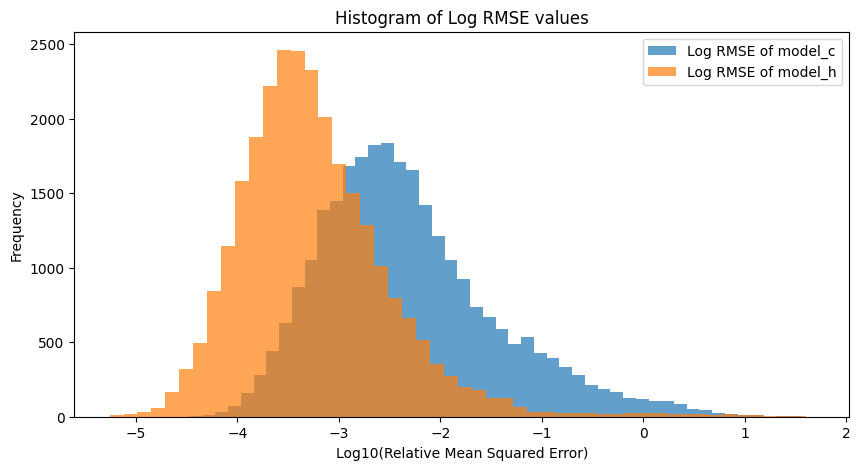

RMSE at c = 2: Mean = 0.03745646774768829, Std = 0.1764228641986847
RMSE at c = 3: Mean = 0.049240369349718094, Std = 0.22031308710575104
RMSE at c = 4: Mean = 0.09308957308530807, Std = 0.2961278259754181


In [17]:
# Use trained model to make predictions
predictions_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca))  # Ensure model_c is defined
predictions_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca))  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.mean((predictions_c - data_c_test) ** 2 / (data_c_test ** 2), axis=1)  # Averaging across time points
rmse_h = np.mean((predictions_h - data_h_test) ** 2 / (data_h_test ** 2), axis=1)  # Averaging across time points

print(np.mean(rmse_c), np.mean(rmse_h))

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points = [2, 3, 4]
errors_at_special_points = {str(point): [] for point in special_points}

for i in range(data_c_test.shape[0]):
    for point in special_points:
        if np.max(data_c_test[i])>=point:
            index = np.argmin(np.abs(data_c_test[i]-point))
            errors_at_special_points[str(point)].append(np.abs((predictions_c[i, index] - data_c_test[i, index])**2))

# Print analysis for special points
for point, errors in errors_at_special_points.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")


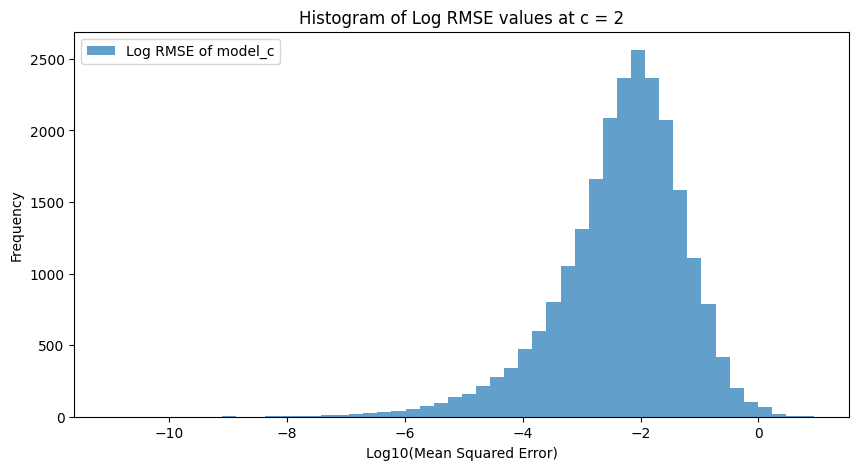

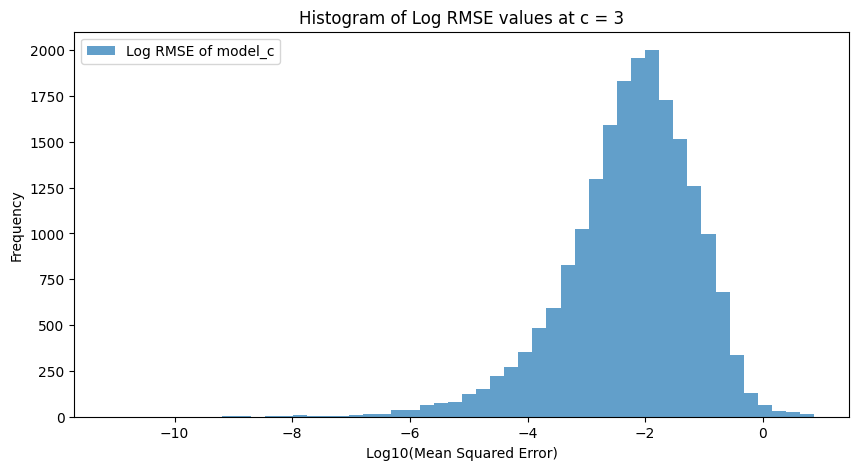

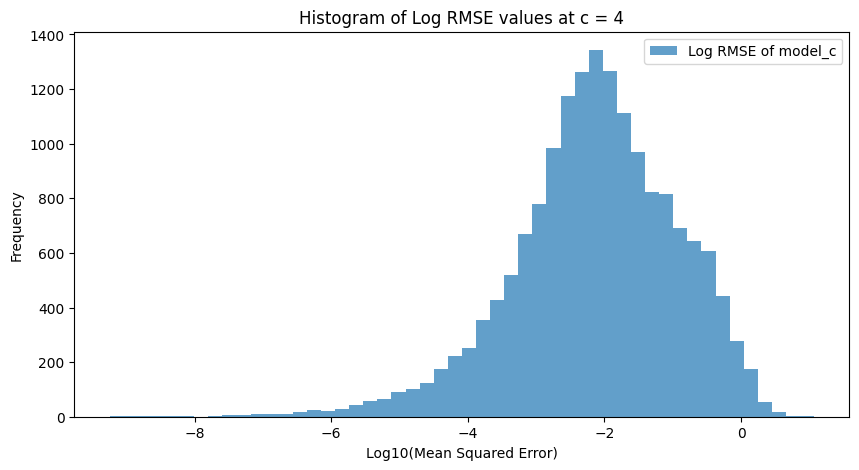

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["2"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 2')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["3"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 3')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["4"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 4')
plt.legend()
plt.show()

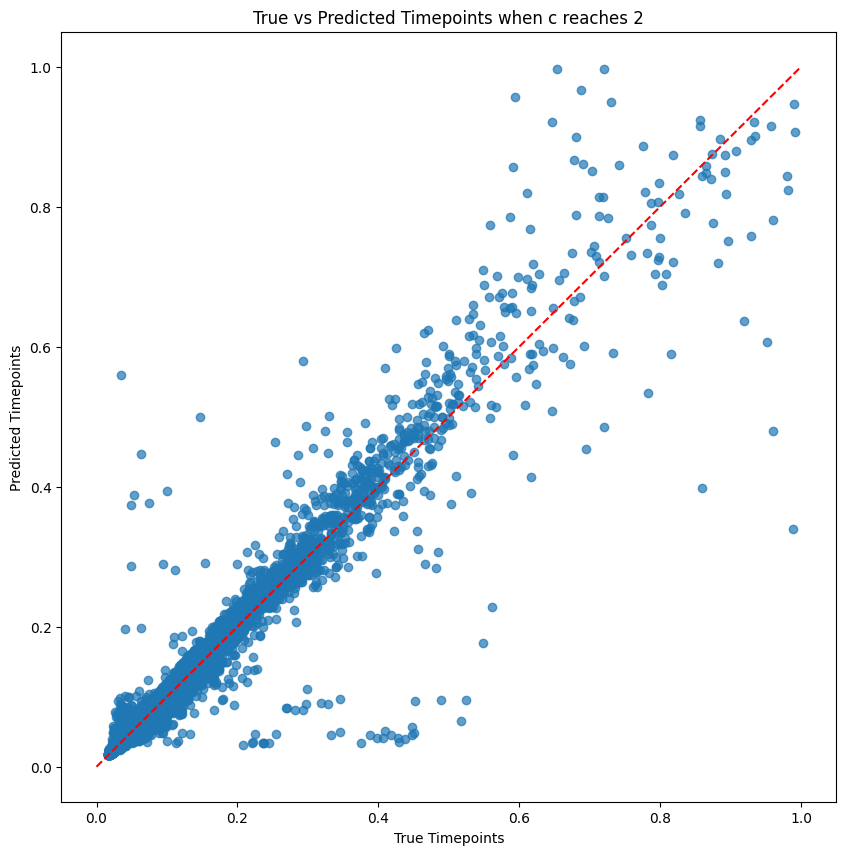

In [19]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 2)[0]
    pred_indices = np.where(predictions_c[i] >= 2)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 2')
plt.show()

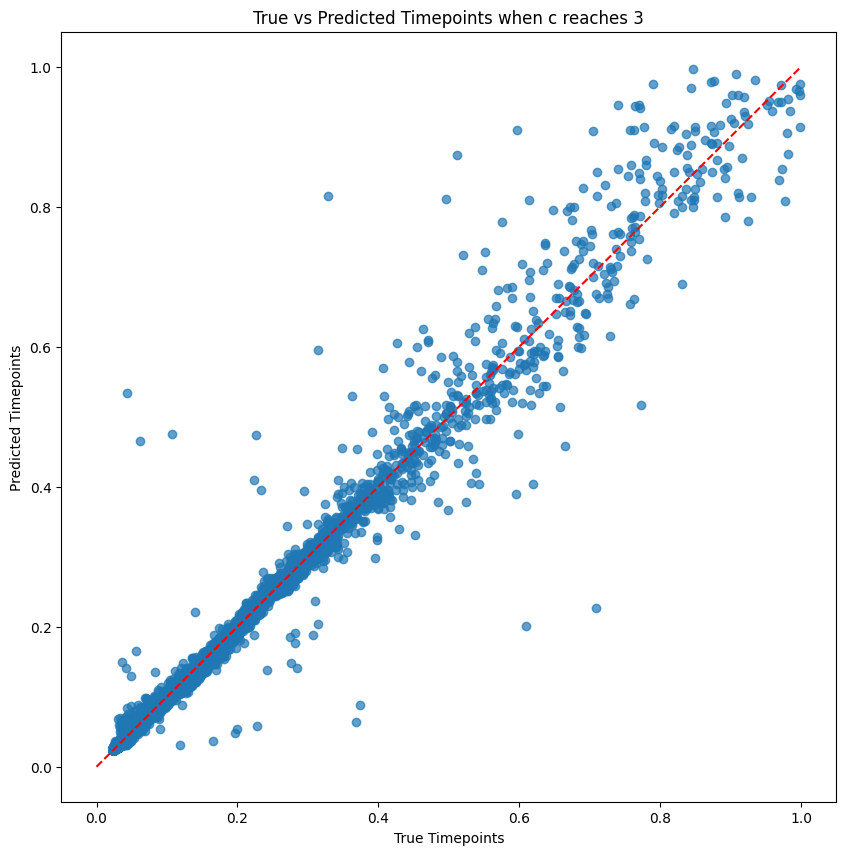

In [20]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 3)[0]
    pred_indices = np.where(predictions_c[i] >= 3)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 3')
plt.show()

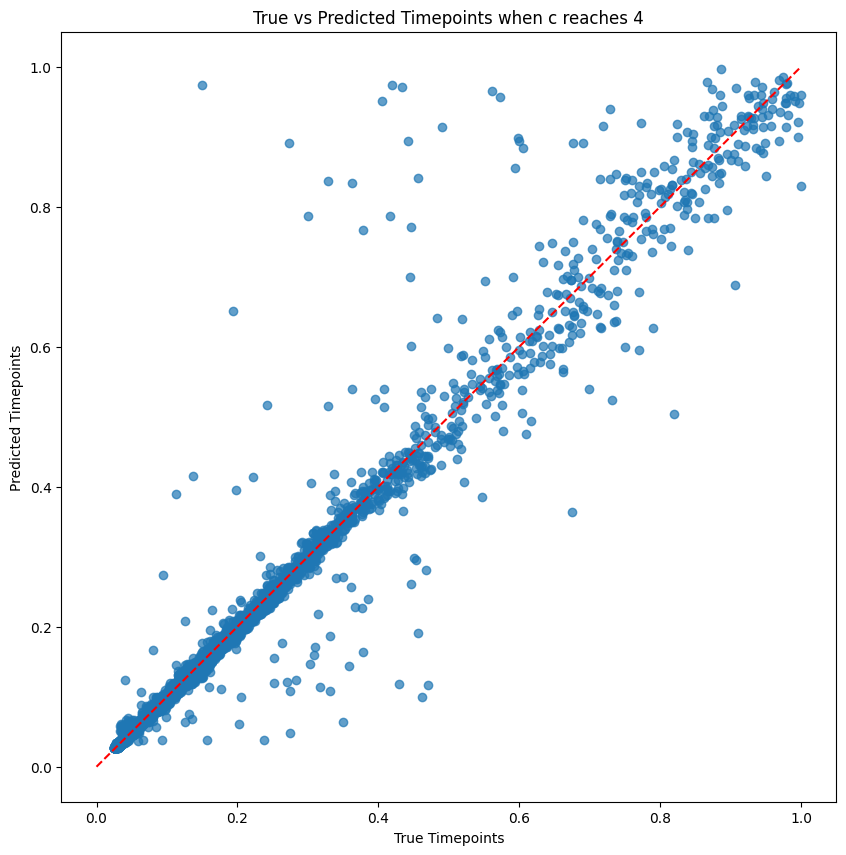

In [21]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 4)[0]
    pred_indices = np.where(predictions_c[i] >= 4)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 4')
plt.show()

In [22]:
import numpy as np

def find_sharpest_decline_point(data, mesh=np.linspace(0, 1, 601)):
    """
    Identifies the point where the second derivative is smallest for each function in the input matrix.
    
    Parameters:
        data (numpy.ndarray): A matrix of shape [n, 601] where each row represents a discretized function.
        mesh (numpy.ndarray): The mesh points corresponding to the function values (default: linspace(0, 1, 601)).
    
    Returns:
        numpy.ndarray: An array of shape [n] containing the mesh points where the second derivative is minimum.
    """
    h = mesh[1] - mesh[0]  # Step size
    n = data.shape[0]

    # Compute second derivative using finite difference approximation
    second_derivative = (data[:, :-2] + data[:, 2:] - 2 * data[:, 1:-1]) / (h ** 2)

    # Find the index of the minimum second derivative for each row
    min_indices = np.argmin(second_derivative, axis=1)

    # Map indices to corresponding mesh points
    min_points = mesh[min_indices + 1]  # +1 because second_derivative skips first and last points

    return min_points, min_indices

In [23]:
sharpest_points, sharpest_indices = find_sharpest_decline_point(data_c_test)

errors_at_sharpest_points = []

for i in range(data_c_test.shape[0]):
    errors_at_sharpest_points.append(np.abs((predictions_c[i, sharpest_indices[i]] - data_c_test[i, sharpest_indices[i]])**2))


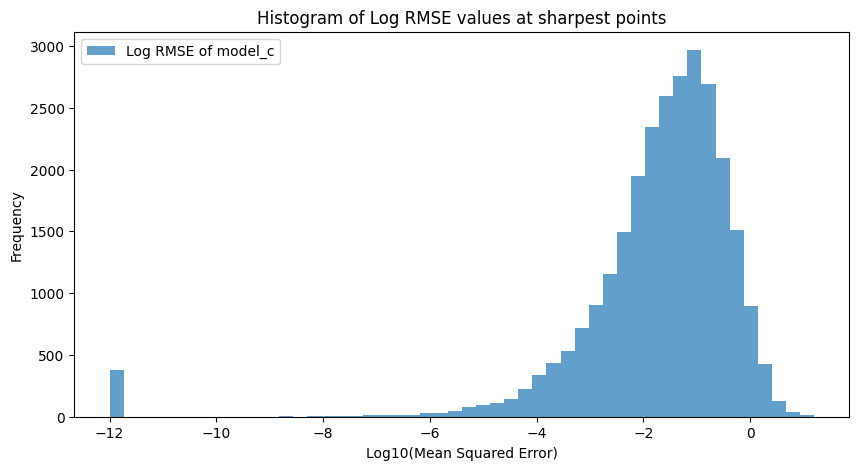

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_sharpest_points]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at sharpest points')
plt.legend()
plt.show()

In [25]:
# Calculate log10 of errors at sharpest points
log_errors_at_sharpest_points = np.log10([error + 1e-12 for error in errors_at_sharpest_points])

# Find indices where log_errors_at_sharpest_points is less than 1e-10
indices = np.where(log_errors_at_sharpest_points < -10)[0]

# List all the values from data_c_test at these indices
values = data_c_test[indices]

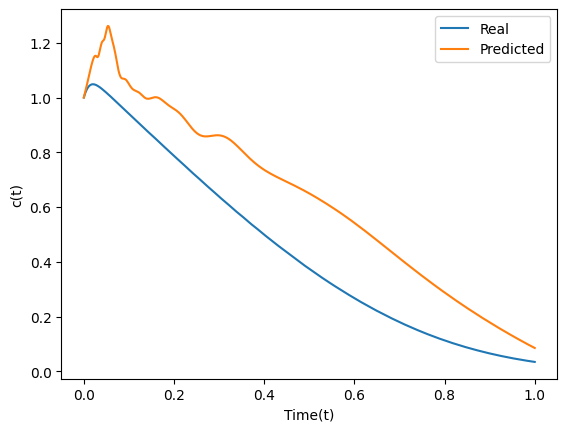

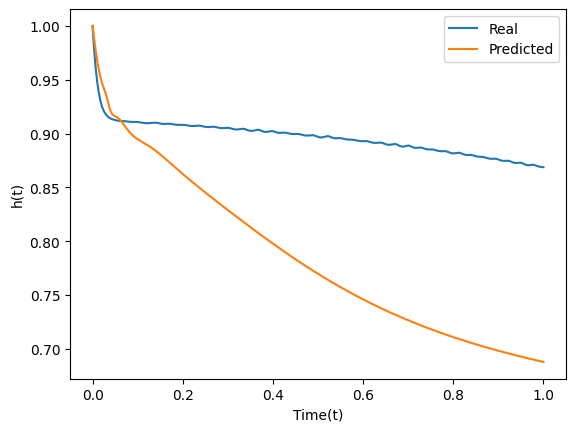

In [26]:
n = np.random.choice(indices)
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

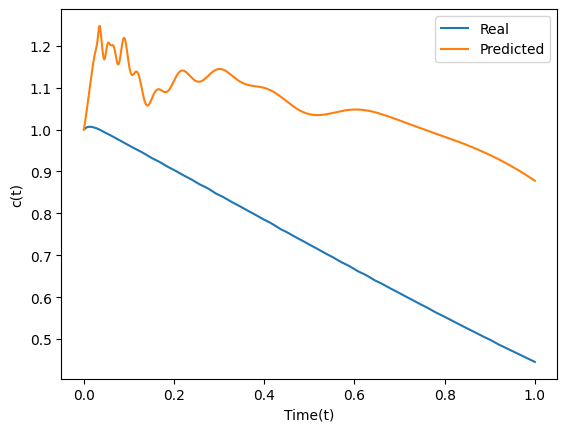

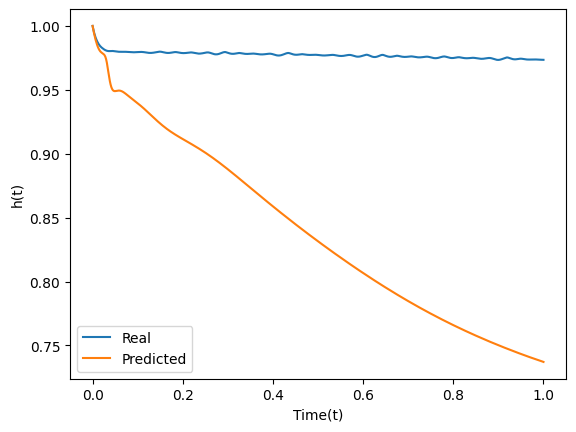

In [27]:
n = np.random.choice(indices)
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

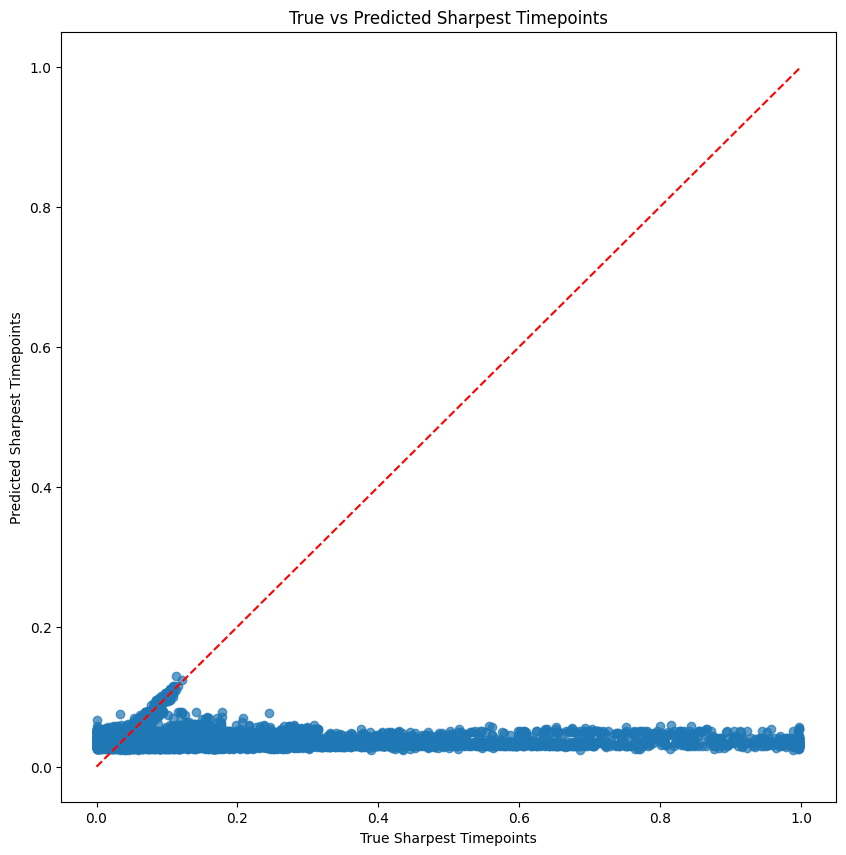

In [28]:
# Identify the timepoints where the true value and predicted value of c have the highest second derivative
true_sharpest_timepoints = []
pred_sharpest_timepoints = []

# Use the find_sharpest_decline_point function to find the sharpest decline points for predictions_c
_, pred_sharpest_indices = find_sharpest_decline_point(predictions_c)

for i in range(data_c_test.shape[0]):
    true_sharpest_timepoints.append(t[sharpest_indices[i]])
    pred_sharpest_timepoints.append(t[pred_sharpest_indices[i]])

# Convert lists to numpy arrays for plotting
true_sharpest_timepoints = np.array(true_sharpest_timepoints)
pred_sharpest_timepoints = np.array(pred_sharpest_timepoints)

# Plot the true sharpest timepoints against the predicted sharpest timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_sharpest_timepoints, pred_sharpest_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Sharpest Timepoints')
plt.ylabel('Predicted Sharpest Timepoints')
plt.title('True vs Predicted Sharpest Timepoints')
plt.show()

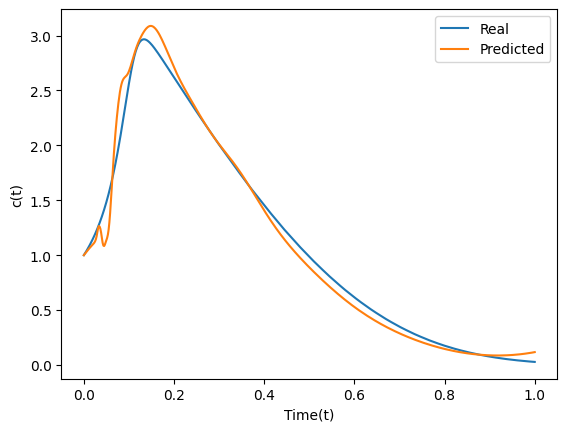

In [29]:
n = np.random.randint(0, len(data_h_test))
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

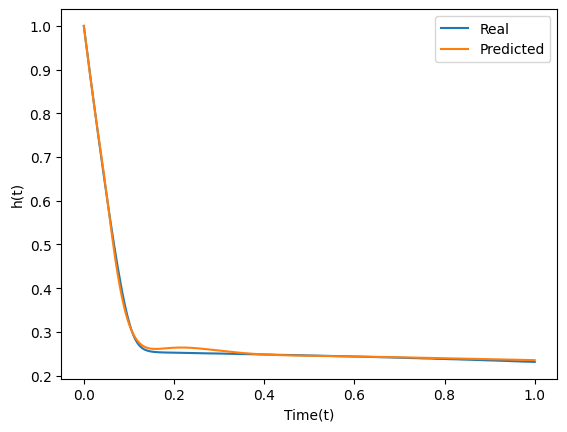

In [30]:
pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

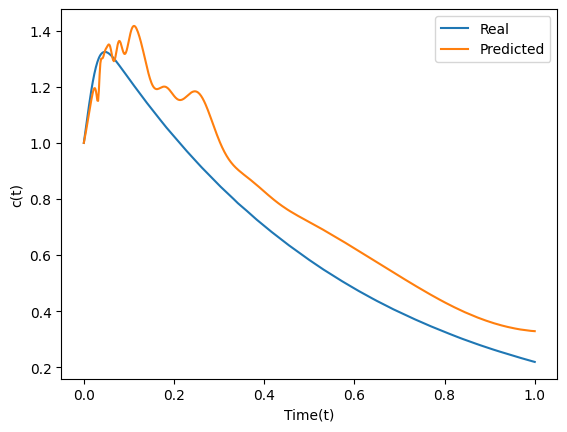

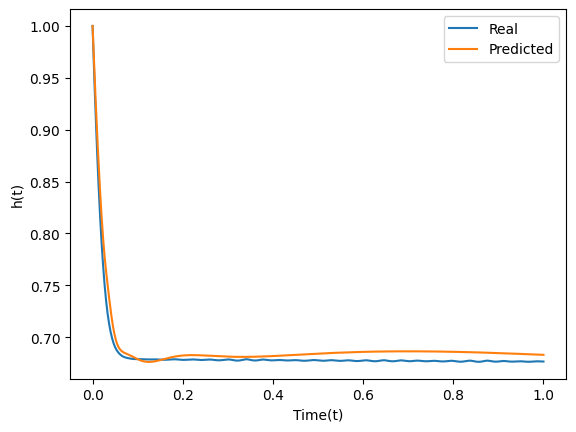

In [31]:
n = np.random.randint(0, len(data_h_test))
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

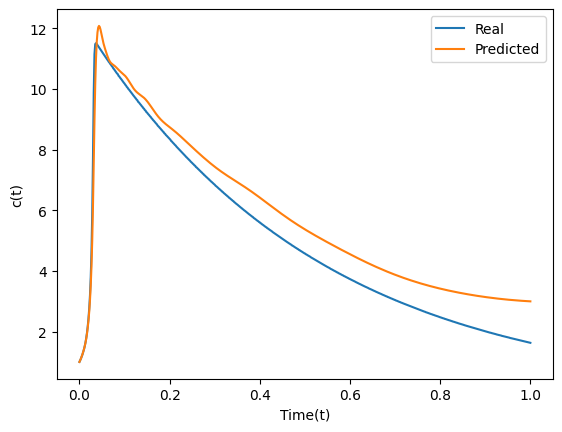

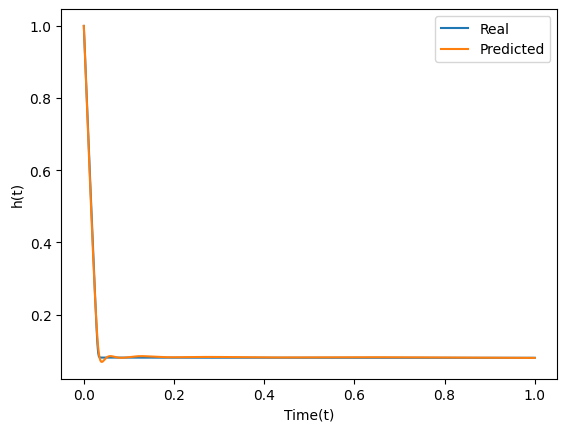

In [32]:
n = np.random.randint(0, len(data_h_test))
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

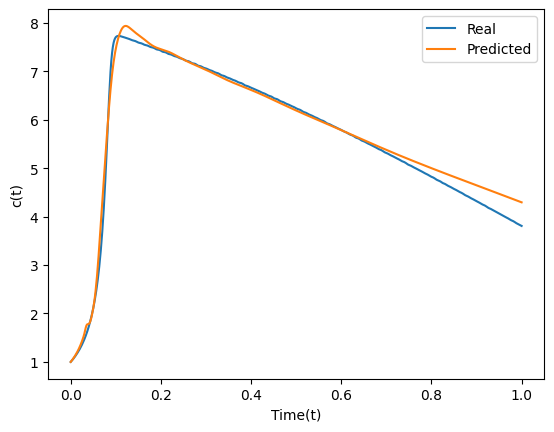

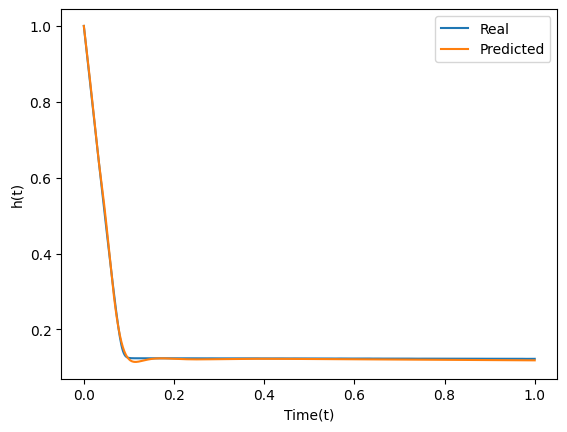

In [33]:
n = np.random.randint(0, len(data_h_test))
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

In [34]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca"
# model_c.save(path)

In [35]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca"
# model_h.save(path)

In [38]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/all_data_1d_glob.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["data_I"]))

data_c_glob = np.array(np.array(datastore_glob["data_c"]))
data_h_glob = np.array(np.array(datastore_glob["data_h"]))


In [39]:
# Prepare the test data
X_test_glob = data_I_glob.astype(np.float32)
y_test_c_glob = data_c_glob.astype(np.float32)
y_test_h_glob = data_h_glob.astype(np.float32)

# Use trained models to make predictions
predictions_c_glob = model_c.predict(X_test_glob)
predictions_h_glob = model_h.predict(X_test_glob)

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c_glob = np.mean((predictions_c_glob - y_test_c_glob) ** 2 / (y_test_c_glob ** 2 + 1e-12), axis=1)
rmse_h_glob = np.mean((predictions_h_glob - y_test_h_glob) ** 2 / (y_test_h_glob ** 2 + 1e-12), axis=1)

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c_glob + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h_glob + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points_glob = [2, 3, 4]
errors_at_special_points_glob = {str(point): [] for point in special_points_glob}

for i in range(y_test_c_glob.shape[0]):
    for point in special_points_glob:
        if np.max(y_test_c_glob[i]) >= point:
            index = np.argmin(np.abs(y_test_c_glob[i] - point))
            errors_at_special_points_glob[str(point)].append(np.abs((predictions_c_glob[i, index] - y_test_c_glob[i, index]) ** 2))

# Print analysis for special points
for point, errors in errors_at_special_points_glob.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")

# Find the sharpest decline points
sharpest_points_glob, sharpest_indices_glob = find_sharpest_decline_point(y_test_c_glob)

errors_at_sharpest_points_glob = []

for i in range(y_test_c_glob.shape[0]):
    errors_at_sharpest_points_glob.append(np.abs((predictions_c_glob[i, sharpest_indices_glob[i]] - y_test_c_glob[i, sharpest_indices_glob[i]]) ** 2))

# Plot histogram of RMSE values at sharpest points
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_sharpest_points_glob]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at sharpest points for global data')
plt.legend()
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (23695x601 and 10x400)